<a href="https://colab.research.google.com/github/SilvanaBContreras/AA_TP1_G8/blob/main/AA_TP1_G8_AdaBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# boosting

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Levanto datos procesados en notebook EDA

In [3]:
URL_BASE = 'https://github.com/SilvanaBContreras/AA_TP1_G8/raw/refs/heads/main/'

archivos_a_cargar = {
    'X_train_completo.parquet': 'X_train',
    'y_train.parquet': 'y_train',
    'X_test_completo.parquet': 'X_test',
    'y_test.parquet': 'y_test',
    'X_train_reducido.parquet': 'X_train_short',
    'X_test_reducido.parquet': 'X_test_short',
    'X_transf.parquet': 'X_transf',
    'y.parquet': 'y',
    'y_ternaria.parquet': 'y_ternaria',
    'y_ternaria.parquet': 'y_ternaria',
    'X_train_ternaria.parquet': 'X_train_ternaria',
    'X_test_ternaria.parquet': 'X_test_ternaria',
    'y_train_ternaria.parquet': 'y_train_ternaria',
    'y_test_ternaria.parquet': 'y_test_ternaria'
}

def cargar_conjunto(nombre_archivo):
    """Carga un archivo Parquet desde la URL de GitHub."""
    full_url = URL_BASE + nombre_archivo
    data = pd.read_parquet(full_url)

    # Si es un DataFrame con una sola columna (que era originalmente una Series 'y'),
    # la convertimos de vuelta a Series con .squeeze()
    if data.shape[1] == 1:
        return data.squeeze()

    return data

# Crear un diccionario para almacenar todas las variables cargadas
variables_cargadas = {}

# Cargar y asignar dinámicamente
for nombre_archivo, nombre_variable in archivos_a_cargar.items():
    datos = cargar_conjunto(nombre_archivo)
    variables_cargadas[nombre_variable] = datos
    print(f" Cargado {nombre_archivo} como la variable '{nombre_variable}'")

# Asignar las variables al espacio de nombres de la notebook
X_train = variables_cargadas['X_train']
y_train = variables_cargadas['y_train']
X_test = variables_cargadas['X_test']
y_test = variables_cargadas['y_test']
X_train_short = variables_cargadas['X_train_short']
X_test_short = variables_cargadas['X_test_short']
X_transf = variables_cargadas['X_transf']
y = variables_cargadas['y']
y_ternaria = variables_cargadas['y_ternaria']
X_train_ternaria = variables_cargadas['X_train_ternaria']
X_test_ternaria = variables_cargadas['X_test_ternaria']
y_train_ternaria = variables_cargadas['y_train_ternaria']
y_test_ternaria = variables_cargadas['y_test_ternaria']


print("\n--- Verificación Final ---")
print(f"Variable X_train cargada. Dimensiones: {X_train.shape}")
print(f"Variable X_train_short cargada. Dimensiones: {X_train_short.shape}")
print("¡Estás lista para comenzar a entrenar y comparar modelos! ")

 Cargado X_train_completo.parquet como la variable 'X_train'
 Cargado y_train.parquet como la variable 'y_train'
 Cargado X_test_completo.parquet como la variable 'X_test'
 Cargado y_test.parquet como la variable 'y_test'
 Cargado X_train_reducido.parquet como la variable 'X_train_short'
 Cargado X_test_reducido.parquet como la variable 'X_test_short'
 Cargado X_transf.parquet como la variable 'X_transf'
 Cargado y.parquet como la variable 'y'
 Cargado y_ternaria.parquet como la variable 'y_ternaria'
 Cargado X_train_ternaria.parquet como la variable 'X_train_ternaria'
 Cargado X_test_ternaria.parquet como la variable 'X_test_ternaria'
 Cargado y_train_ternaria.parquet como la variable 'y_train_ternaria'
 Cargado y_test_ternaria.parquet como la variable 'y_test_ternaria'

--- Verificación Final ---
Variable X_train cargada. Dimensiones: (40257, 51)
Variable X_train_short cargada. Dimensiones: (40257, 49)
¡Estás lista para comenzar a entrenar y comparar modelos! 


In [4]:
print("\nDimensiones de:")
print(f"X_transf: {X_transf.shape}")
print(f"y: {y.shape}")

print(f"X_train: {X_train.shape}")
print(f"X_train_short: {X_train_short.shape}")
print(f"X_test: {X_test.shape}")
print(f"X_test_short: {X_test_short.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")
print(f"y_ternaria: {y_ternaria.shape}")
print(f"y_train_ternaria: {y_train_ternaria.shape}")
print(f"y_test_ternaria: {y_test_ternaria.shape}")


Dimensiones de:
X_transf: (57510, 51)
y: (57510,)
X_train: (40257, 51)
X_train_short: (40257, 49)
X_test: (17253, 51)
X_test_short: (17253, 49)
y_train: (40257,)
y_test: (17253,)
y_ternaria: (57510,)
y_train_ternaria: (40257,)
y_test_ternaria: (17253,)


In [5]:
print(f"y_ternaria: {y_ternaria.shape}")

y_ternaria: (57510,)


In [6]:
y_ternaria.value_counts()

,count
target_ternaria,
2,35685
1,14087
0,7738


# ADA BOOST


## Optimizacion hiperparametros

In [7]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score
)

# Modelo base (stump por defecto)
ada = AdaBoostClassifier(random_state=42)

# Búsqueda de hiperparámetros
param_dist = {
    "n_estimators": np.arange(50, 301, 5),
    "learning_rate": np.linspace(0.01, 1.0, 100)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    ada,
    param_distributions=param_dist,
    n_iter=40,
    scoring="f1_weighted",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=0
)

search.fit(X_train_ternaria, y_train_ternaria)
best_ada = search.best_estimator_

print("AdaBoost (ternaria) - Mejores hiperparámetros")
print(search.best_params_)
print(f"CV F1_weighted (best): {search.best_score_:.4f}")


# Entrenar el mejor modelo y reportar en TEST
best_ada.fit(X_train_ternaria, y_train_ternaria)

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

y_pred = best_ada.predict(X_test_ternaria)

print("\n Classification report (test) ")
print(classification_report(
    y_test_ternaria, y_pred,
    target_names=['Graduado', 'En Curso', 'Desertor'],
    digits=3, zero_division=0
))




AdaBoost (ternaria) - Mejores hiperparámetros
{'n_estimators': np.int64(295), 'learning_rate': np.float64(0.9500000000000001)}
CV F1_weighted (best): 0.7746

=== Classification report (test) ===
              precision    recall  f1-score   support

    Graduado      0.701     0.435     0.537      2321
    En Curso      0.621     0.595     0.608      4226
    Desertor      0.848     0.932     0.888     10706

    accuracy                          0.783     17253
   macro avg      0.723     0.654     0.678     17253
weighted avg      0.773     0.783     0.772     17253



## Resumen mejor modelo

AdaBoost (ternaria) - Mejores hiperparámetros
{'n_estimators': np.int64(295), 'learning_rate': np.float64(0.9500000000000001)}
CV F1_weighted (best): 0.7746

--- Métricas en TEST (resumen) ---
Accuracy         : 0.7826
Precision weighted: 0.7727 | macro: 0.7234
Recall    weighted: 0.7826 | macro: 0.6540
F1        weighted: 0.7722 | macro: 0.6776

--- Classification report (TEST) ---
              precision    recall  f1-score   support

    Graduado      0.701     0.435     0.537      2321
    En Curso      0.621     0.595     0.608      4226
    Desertor      0.848     0.932     0.888     10706

    accuracy                          0.783     17253
   macro avg      0.723     0.654     0.678     17253
weighted avg      0.773     0.783     0.772     17253



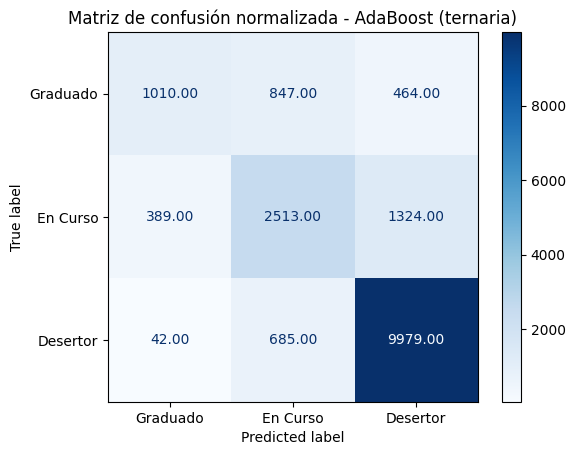

ROC-AUC OVO (macro): 0.8227


In [10]:
#  Resumen CV
print("AdaBoost (ternaria) - Mejores hiperparámetros")
print(search.best_params_)
print(f"CV F1_weighted (best): {search.best_score_:.4f}")

#  Evaluación en TEST
best_ada = search.best_estimator_
best_ada.fit(X_train_ternaria, y_train_ternaria)

y_pred = best_ada.predict(X_test_ternaria)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)

# Métricas agregadas (macro/weighted)
acc  = accuracy_score(y_test_ternaria, y_pred)
prec_w = precision_score(y_test_ternaria, y_pred, average="weighted", zero_division=0)
rec_w  = recall_score(y_test_ternaria, y_pred, average="weighted", zero_division=0)
f1_w   = f1_score(y_test_ternaria, y_pred, average="weighted", zero_division=0)
prec_m = precision_score(y_test_ternaria, y_pred, average="macro", zero_division=0)
rec_m  = recall_score(y_test_ternaria, y_pred, average="macro", zero_division=0)
f1_m   = f1_score(y_test_ternaria, y_pred, average="macro", zero_division=0)

print("\n--- Métricas en TEST (resumen) ---")
print(f"Accuracy         : {acc:.4f}")
print(f"Precision weighted: {prec_w:.4f} | macro: {prec_m:.4f}")
print(f"Recall    weighted: {rec_w:.4f} | macro: {rec_m:.4f}")
print(f"F1        weighted: {f1_w:.4f} | macro: {f1_m:.4f}")

print("\n--- Classification report (TEST) ---")
print(classification_report(
    y_test_ternaria, y_pred,
    target_names=['Graduado', 'En Curso', 'Desertor'],
    digits=3, zero_division=0
))

# Matriz de confusión normalizada
cm = confusion_matrix(y_test_ternaria, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Graduado', 'En Curso', 'Desertor'])
disp.plot(values_format=".2f", cmap="Blues")
plt.title("Matriz de confusión - AdaBoost (ternaria)")
plt.show()

# ROC-AUC macro OVO para multiclase (para comparar AUC)
try:
    y_proba = best_ada.predict_proba(X_test_ternaria)
    auc_macro_ovo = roc_auc_score(y_test_ternaria, y_proba,
                                  multi_class="ovo", average="macro")
    print(f"ROC-AUC OVO (macro): {auc_macro_ovo:.4f}")
except Exception as e:
    print("No fue posible calcular ROC-AUC OVO:", e)


## Curva de complejidad

In [ ]:

# Curva de complejidad: variamos n_estimators con el learning_rate óptimo
best_lr = search.best_params_["learning_rate"]
n_grid = np.arange(25, 401, 25)

cv_scores = []
for n in n_grid:
    mdl = AdaBoostClassifier(n_estimators=n, learning_rate=best_lr, random_state=42)
    s = cross_val_score(mdl, X_train_ternaria, y_train_ternaria,
                        cv=cv, scoring="f1_weighted", n_jobs=-1)
    cv_scores.append(s.mean())

plt.figure(figsize=(6,4))
plt.plot(n_grid, cv_scores, marker="o")
plt.xlabel("n_estimators")
plt.ylabel("CV F1_weighted")
plt.title("Curva de complejidad - AdaBoost (ternaria)")
plt.grid(True)
plt.show()

# 4) Entrenamiento final y métricas en TEST
best_ada.fit(X_train_ternaria, y_train_ternaria)
y_pred = best_ada.predict(X_test_ternaria)

print("\n Classification report (test)")
print(classification_report(
    y_test_ternaria, y_pred,
    target_names=['Graduado', 'En Curso', 'Desertor'],  # 0,1,2 según tu mapping
    digits=3, zero_division=0
))



## Importancia de variables

In [ ]:

imp = pd.Series(
    best_ada.feature_importances_,
    index=getattr(X_train_ternaria, "columns", range(X_train_ternaria.shape[1]))
).sort_values(ascending=False)

topk = 15
plt.figure(figsize=(8,6))
imp.head(topk).iloc[::-1].plot(kind="barh")
plt.title("Importancia de variables - AdaBoost (ternaria)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()